In [ ]:
#| default_exp cdp

# CDP — network sniffing and replay

The cdp module wraps Chrome's DevTools Protocol behind a synchronous interface. `cdp_connect()` is the single entry point: it connects to a debug-enabled Chrome on `port` (9223 by default), and if none is running it calls `cdp_setup()` to start one on a persistent profile dir (`~/.cache/fastcdp/cdp-chrome`) first. The profile persists across runs, so cookies and sessions survive — for SSO or enterprise sites, log in once in the browser window and every subsequent call picks up that session automatically.

Use cdp when scrapling's stealth mode is not enough: the site checks for enterprise SSO, reads cookies from a previous session, or ties requests to a specific browser fingerprint.

In [ ]:
#| export
import asyncio, json, base64, time, subprocess, sys, shutil, os, threading, socket, tempfile, re
from fastcore.all import patch, store_attr, AttrDict, Path, first, L
from fastcdp import *
from fossick.core import *
from scrapling import Selector
from importlib.resources import files as _pkg_files
from functools import lru_cache, wraps
from collections import defaultdict

In [ ]:
#| export
def _debug_running(port, host='127.0.0.1'):
    "True if a debug Chrome is already accepting connections on `port`"
    with socket.socket() as s:
        s.settimeout(0.3)
        return s.connect_ex((host, port)) == 0

def _chrome_flags(port, d, headless, extra_flags):
    "Assemble Chrome launch flags; auto-adds --no-sandbox when running as root (containers/CI)"
    args = [chrome_bin(), f'--remote-debugging-port={port}', f'--user-data-dir={d}',
            '--no-first-run', '--no-default-browser-check']
    if headless: args.append('--headless=new')
    if hasattr(os, 'geteuid') and os.geteuid() == 0: args.append('--no-sandbox')
    return args + list(extra_flags or [])

async def cdp_setup(port=9223, user_data_dir=None, headless=False, timeout=15, extra_flags=None):
    "Start a persistent debug Chrome on `port` with its own profile, ready for `CDP.remote`"
    d = Path(user_data_dir) if user_data_dir else Path.home()/'.cache'/'fastcdp'/'cdp-chrome'
    d.mkdir(parents=True, exist_ok=True)
    args = _chrome_flags(port, d, headless, extra_flags)
    subprocess.Popen(args, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, start_new_session=True)
    deadline = time.time() + timeout
    while not _debug_running(port):
        if time.time() > deadline: raise TimeoutError(f'Chrome debug endpoint on :{port} not ready')
        await asyncio.sleep(0.1)
    return d

async def cdp_connect(port=9223, user_data_dir=None, headless=False, extra_flags=None):
    "Connect to a debug Chrome on `port`; if none is running, set one up on a persistent profile and connect."
    if not _debug_running(port): await cdp_setup(port, user_data_dir, headless, extra_flags=extra_flags)
    cdp = await CDP.remote(port)
    cdp.ws.protocol.max_message_size = 2**30
    return cdp

def cdp_ws(port=9223, headless=True, user_data_dir=None, extra_flags=None) -> str:
    "Websocket debugger URL of the debug Chrome on `port`, starting one (headless by default) if needed. For scrapling's `cdp_url=`."
    import httpx
    if not _debug_running(port): syncy(cdp_setup(port, user_data_dir, headless, extra_flags=extra_flags))
    return httpx.get(f'http://127.0.0.1:{port}/json/version').json()['webSocketDebuggerUrl']

In [ ]:
#| export
_loop = None
def _bridge():
	global _loop
	if _loop is None:
	    _loop = asyncio.new_event_loop()
	    threading.Thread(target=_loop.run_forever, daemon=True).start()
	return _loop

def syncy(coro, tout=60): return asyncio.run_coroutine_threadsafe(coro, _bridge()).result(timeout=tout)

In [ ]:
#| export
@patch
async def open_page(self:CDP, url):
	pg = await self.new_page()
	await pg.goto(url)
	return pg

In [ ]:
cdp = syncy(cdp_connect())
assert cdp.is_open

In [ ]:
pgs = syncy(cdp.pages)
if pgs:
    tid = pgs[0]['targetId']
    sid = syncy(cdp.attach(tid))
    pg=Page(cdp, tid, sid)
    root = syncy(pg.ax_tree())
    print(str(root)[:300])

- **RootWebArea** "New Tab" `focusable=True` `url=chrome://new-tab-page/` [#1]
  - **Iframe** "" [#22]
  - **image** "" `url=data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAfQAAADICAYAAAAeGRPoAADZQElEQVR4AezBgQAAAACAoP2pF6kCAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAJi9swBS5crC8C1X1pcYMbZCpUhCtki6wlZv71IkhBB2d


In [ ]:
#| eval: false
page = syncy(cdp.new_page())
syncy(page.goto('https://vedicreader.com/s/'))
rt = syncy(page.ax_tree())
print(str(rt)[:300])

- **RootWebArea** "VedicReader" `focusable=True` `focused=True` `url=https://vedicreader.com/` [#2]
  - **navigation** "" [#182]
    - **link** "Vr." `focusable=True` `url=https://vedicreader.com/` [#183]
      - **heading** "Vr." `level=4` [#184]
        - **StaticText** "Vr." [#262]
          - **


In [ ]:
#| eval: false
syncy(page.click(rt.find_id('button', 'Test Drive')))

In [ ]:
#| export
@patch
async def calls(self:CDP, url=None, pattern='.*', tail=3):
    'Outgoing requests matching `pattern`. Navigates if url given, else passive.'
    page = await self.new_page()
    rx, out = compile_pattern(pattern), {}
    await page.network.enable()
    async with self.on('Network.requestWillBeSent') as q:
        async with self.on('Network.loadingFinished') as done:
            async def drain():
                while True:
                    m = await q.get()
                    if m.get('sessionId') not in (None, page.sid): continue
                    r, rid = m['params']['request'], m['params']['requestId']
                    if rx.search(r['url']): out[rid] = r|dict(rid=rid)
            d = asyncio.create_task(drain())
            if url: await page.goto(url)
            else: await asyncio.sleep(tail)
            await asyncio.sleep(tail)
            d.cancel()
            while not done.empty():
                m = await done.get()
                if (rid:=m['params']['requestId']) not in out: continue
                body = await self.network.getResponseBody(requestId=rid, sid=page.sid)
                out[rid]= out[rid] | dict(response_body=body)
    return out

In [ ]:
#| export
async def _get_cookies(cdp, urls=None):
    "Raw CDP cookies (dicts) from the running browser, optionally scoped to `urls`"
    pg = first(await cdp.pages)
    sid = await cdp.attach(pg['targetId']) if pg else None
    kw = dict(urls=urls) if urls else {}
    await cdp.network.enable(sid=sid)
    ck = await cdp.network.getCookies(sid=sid, **kw)
    return ck if isinstance(ck, list) else ck.get('cookies', ck)

def cdp_cookies(url_or_domain=None, port=9223, as_dict=False):
    "Export cookies from the running debug Chrome. Returns Playwright-format list (for scrapling `cookies=`), or `{name: value}` if `as_dict`."
    urls = None
    if url_or_domain:
        u = url_or_domain if '://' in url_or_domain else f'https://{url_or_domain}'
        urls = [u]
    async def _run():
        cdp = await cdp_connect(port=port)
        return await _get_cookies(cdp, urls)
    raw = syncy(_run())
    if as_dict: return {c['name']: c['value'] for c in raw}
    keep = ('name', 'value', 'domain', 'path', 'expires', 'httpOnly', 'secure', 'sameSite')
    out = []
    for c in raw:
        d = {k: c[k] for k in keep if k in c}
        if d.get('sameSite') not in ('Strict', 'Lax', 'None'): d.pop('sameSite', None)
        if d.get('expires', 0) in (-1, 0): d.pop('expires', None)
        out.append(d)
    return out

In [ ]:
#| export
@patch
async def html(self:Page):
    "Live outerHTML of the page (post-JS), as a string"
    return await self.eval('document.documentElement.outerHTML')

@patch
async def selector(self:Page):
    "Live page as a scrapling `Selector` for CSS/xpath querying"
    return Selector(await self.html(), url=await self.eval('location.href'))

@patch
async def md(self:Page, sel:str=None, **kw):
    "Live page as clean markdown via fossick's `to_md` (optionally narrowed to CSS `sel`)"
    return to_md(await self.html(), sel=sel, **kw)

In [ ]:
#| export
_INTERACTIVE = {'button','link','textbox','searchbox','combobox','checkbox','radio','switch',
                'tab','menuitem','menuitemcheckbox','menuitemradio','option','slider','spinbutton',
                'listbox','textarea'}
_STRUCT = {'heading','main','navigation','form','dialog','alert','article'}
_EDITABLE = {'textbox','searchbox','combobox','textarea','spinbutton'}

def _ax_lines(node, interactive, keep, out):
    role = node.role
    show = (role in _INTERACTIVE) if interactive else (role in keep)
    if not interactive and role in _STRUCT: show = True
    if show and node.backend_id:
        ps = ' '.join(f'{k}={v}' for k, v in node.props.items()
                      if v not in (False, None, '', 'false') and k in ('checked','selected','expanded','disabled','required','value','placeholder'))
        nm = (node.name or '')[:80]
        out.append(f'[#{node.backend_id}] {role} "{nm}"' + (f' ({ps})' if ps else ''))
    for c in node.children: _ax_lines(c, interactive, keep, out)
    return out

@patch
async def snapshot(page:Page, interactive=True, keep=None):
    "Compact, LLM-ready view of the page: one line per actionable element as `[#backend_id] role \"name\"`. IDs feed `fill_text`/`click`."
    tree = await page.ax_tree()
    url = await page.eval('location.href'); title = await page.eval('document.title')
    body = '\n'.join(_ax_lines(tree, interactive, keep or (_INTERACTIVE | _STRUCT), [])) if tree else '(empty)'
    return f'# {title}\n{url}\n\n{body}'

@patch
async def type_text(page:Page, backendNodeId, text):
    "Clear an input then type `text` (unlike raw `fill_text`, which appends)."
    await page.js_node_run('this.value="";this.dispatchEvent(new Event("input",{bubbles:true}))', backendNodeId)
    await page.fill_text(backendNodeId, str(text))

@patch
async def click_settle(page:Page, backendNodeId, timeout=8):
    "Click, then best-effort wait for the page to settle — tolerates SPA clicks that don't navigate (unlike `click_and_wait`)."
    await page.click(backendNodeId)
    try: await asyncio.wait_for(page.wait_for_ready(timeout=timeout), timeout+1)
    except Exception: pass

@patch
async def fill_form(page:Page, fields:dict, submit:str=None):
    "Fill a form by field label/name: {label: value}. Native <select> uses its option values. Optionally click `submit` (by name) and wait. Returns snapshot()."
    tree = await page.ax_tree()
    for label, value in fields.items():
        node = first(n for r in _EDITABLE for n in tree.find_all(role=r) if label.lower() in (n.name or '').lower())
        if node is None: node = tree.find(name=label)
        if node is None or not node.backend_id: raise ValueError(f'No editable field matching {label!r}')
        if node.role in ('combobox','listbox') and node.find_all(role='option'):
            await page.select_option(node.backend_id, value)
        else:
            await page.type_text(node.backend_id, value)
    if submit:
        tree = await page.ax_tree()
        bid = tree.find_id(role='button', name=submit) or tree.find_id(role='link', name=submit)
        if bid is None: raise ValueError(f'No button/link matching {submit!r}')
        await page.click_settle(bid)
    return await page.snapshot()

In [ ]:
#| export
def ax_diff(before:str, after:str) -> str:
    "Line diff between two `snapshot()`s (ignoring backend ids, which churn on navigation) — what an action changed."
    import difflib
    strip = lambda s: [re.sub(r'^\[#\d+\]\s*', '', l) for l in s.splitlines()]
    d = [l for l in difflib.unified_diff(strip(before), strip(after), lineterm='', n=0)
         if l and l[0] in '+-' and not l.startswith(('+++','---'))]
    return '\n'.join(d) or '(no change)'

@patch
async def node_for(page:Page, sel:str):
    "backendNodeId of the first element matching CSS `sel` (bridge scrapling/CSS knowledge to CDP actions)."
    doc = await page.DOM.getDocument(depth=0)
    root = doc['root']['nodeId'] if isinstance(doc, dict) and 'root' in doc else doc['nodeId']
    nid = await page.DOM.querySelector(nodeId=root, selector=sel)
    if not nid: return None
    return (await page.DOM.describeNode(nodeId=nid))['backendNodeId']

@patch
async def click_sel(page:Page, sel:str, wait=True):
    "Click the element matching CSS `sel`."
    bid = await page.node_for(sel)
    if bid is None: raise ValueError(f'No element matching {sel!r}')
    await (page.click_and_wait(bid) if wait else page.click(bid))

@patch
async def fill_sel(page:Page, sel:str, text:str):
    "Clear and type `text` into the element matching CSS `sel`."
    bid = await page.node_for(sel)
    if bid is None: raise ValueError(f'No element matching {sel!r}')
    await page.type_text(bid, text)

In [ ]:
#| export
@patch
async def act(page:Page, steps:list):
    "Run a declarative flow; returns {read_label_or_index: markdown} for every ('read', sel) step. Re-reads the ax tree after nav.\n\nSteps: ('goto',url) ('fill',label,val) ('click',label) ('select',label,val) ('wait',text) ('wait_sel',css) ('read',css[,label])."
    reads, tree = {}, None
    async def _tree():
        nonlocal tree; tree = await page.ax_tree(); return tree
    for step in steps:
        op = step[0]
        if op == 'goto': await page.goto(step[1]); tree = None
        elif op == 'fill':
            if tree is None: await _tree()
            bid = first(n.backend_id for r in _EDITABLE for n in tree.find_all(role=r) if step[1].lower() in (n.name or '').lower())
            bid = bid or tree.find_id(name=step[1])
            await page.type_text(bid, step[2])
        elif op == 'click':
            if tree is None: await _tree()
            bid = tree.find_id(role='button', name=step[1]) or tree.find_id(role='link', name=step[1]) or tree.find_id(name=step[1])
            await page.click_settle(bid); tree = None
        elif op == 'select':
            if tree is None: await _tree()
            await page.select_option(tree.find_id(name=step[1]), step[2])
        elif op == 'wait': await page.wait_for_text(step[1])
        elif op == 'wait_sel': await page.wait_for_selector(step[1])
        elif op == 'read':
            label = step[2] if len(step) > 2 else step[1]
            reads[label] = await page.md(sel=step[1])
        else: raise ValueError(f'Unknown step op: {op!r}')
    return reads

In [ ]:
#| eval: false
apis = syncy(cdp.calls('https://www.woolworths.com.au/shop/search/products?searchTerm=Apples%20%26%20Pears', pattern='.apis/ui/Search/products'))

In [ ]:
#| export
BUTTON_JS = r'''
(() => {
  const inject = () => {
    if (document.getElementById('__capbar')) return;
    const bar = document.createElement('div'); bar.id='__capbar'; bar.className='__capui';
    Object.assign(bar.style, {position:'fixed', bottom:'20px', right:'20px',
      zIndex:2147483647, display:'flex', gap:'8px', alignItems:'center', font:'14px sans-serif'});
    const btn = t => { const b=document.createElement('button'); b.textContent=t;
      Object.assign(b.style,{padding:'10px 14px', background:'#111', color:'#fff', border:'none',
        borderRadius:'8px', cursor:'pointer', boxShadow:'0 2px 8px rgba(0,0,0,.35)'}); return b; };
    const badge = document.createElement('span'); badge.id='__capn';
    badge.textContent = (localStorage.getItem('__capN')||0) + ' snaps';
    Object.assign(badge.style,{padding:'6px 10px', background:'#333', color:'#fff', borderRadius:'8px'});
    const cap = btn('📸 capture'); cap.onclick = () => window.__cap(JSON.stringify({}));
    const done = btn('✓ done');   done.onclick = () => window.__cap(JSON.stringify({done:true}));
    bar.append(badge, cap, done); document.body.appendChild(bar);
  };
  if (document.readyState === 'loading') addEventListener('DOMContentLoaded', inject);
  else inject();
})()
'''
HIDE = "document.querySelectorAll('.__capui').forEach(b=>b.style.visibility='hidden')"
SHOW = "document.querySelectorAll('.__capui').forEach(b=>b.style.visibility='visible')"

In [ ]:
#| export
@patch
async def collect(page:Page, save_dir=None, prefix=None, stop=None, tout=None, count=None, every_n=None):
	stop, sid = stop or asyncio.Event(), page.sid
	prefix = prefix or await page.eval('document.title')
	save_dir = Path(save_dir) if save_dir else None
	if save_dir: save_dir.mkdir(parents=True, exist_ok=True)
	def save(img, label=None):
		if not save_dir: return img
		f = save_dir / f'{label or prefix}.png'
		f.write_bytes(img.data)
		print('saved', f.name)
		return img, f
	await page.runtime.enable()
	await page.runtime.addBinding(name='__cap')
	ident = await page.page.addScriptToEvaluateOnNewDocument(source=BUTTON_JS)
	await page.eval("localStorage.setItem('__capN','0')")
	await page.eval(BUTTON_JS)
	loop = asyncio.get_event_loop()
	dl = loop.time() + tout if tout else None
	shots, n = [], 0
	def _set(v): return f'''localStorage.setItem('__capN','{v}');var e=document.getElementById('__capn');
	 if(e)e.textContent='{v} snaps';'''

	try:
		async with page.cdp.on('Runtime.bindingCalled') as q:
			print(f'📸 capture, ✓ done (or stop.set()) to finish. → {save_dir}/')
			while not stop.is_set():
				rem = (dl - loop.time()) if dl else None
				if rem is not None and rem <= 0: break
				wait_for = min(every_n, rem) if (every_n and rem is not None) else (every_n or rem)
				get, halt = asyncio.ensure_future(q.get()), asyncio.ensure_future(stop.wait())
				kw = dict(timeout=wait_for) if wait_for is not None else {}
				fin, pend = await asyncio.wait({get, halt}, return_when=asyncio.FIRST_COMPLETED, **kw)
				for p in pend: p.cancel()
				if not fin:
					if every_n and (dl is None or loop.time() < dl):
						img = await page.screenshot()
						shots.append(save(img, f'{prefix}_{n}'))
						n += 1
						await page.eval(_set(n))
						if count and n >= count: break
						continue
					break
				if get not in fin: break
				m = get.result()
				if m.get('sessionId') not in (None, sid) or m['params'].get('name') != '__cap': continue
				data = json.loads(m['params'].get('payload') or '{}')
				if data.get('done'): break
				await page.eval(HIDE)
				await asyncio.sleep(0.05)
				img = await page.screenshot()
				await page.eval(SHOW)
				shots.append(save(img, data.get('label')))
				n += 1
				await page.eval(_set(n))
				if count and n >= count: break
	finally:
		try:
			await page.page.removeScriptToEvaluateOnNewDocument(identifier=ident)
			await page.runtime.removeBinding(name='__cap')
			await page.eval("document.getElementById('__capbar')?.remove(); localStorage.removeItem('__capN')")
		except: pass
	return shots

📸 capture, ✓ done (or stop.set()) to finish. → None/


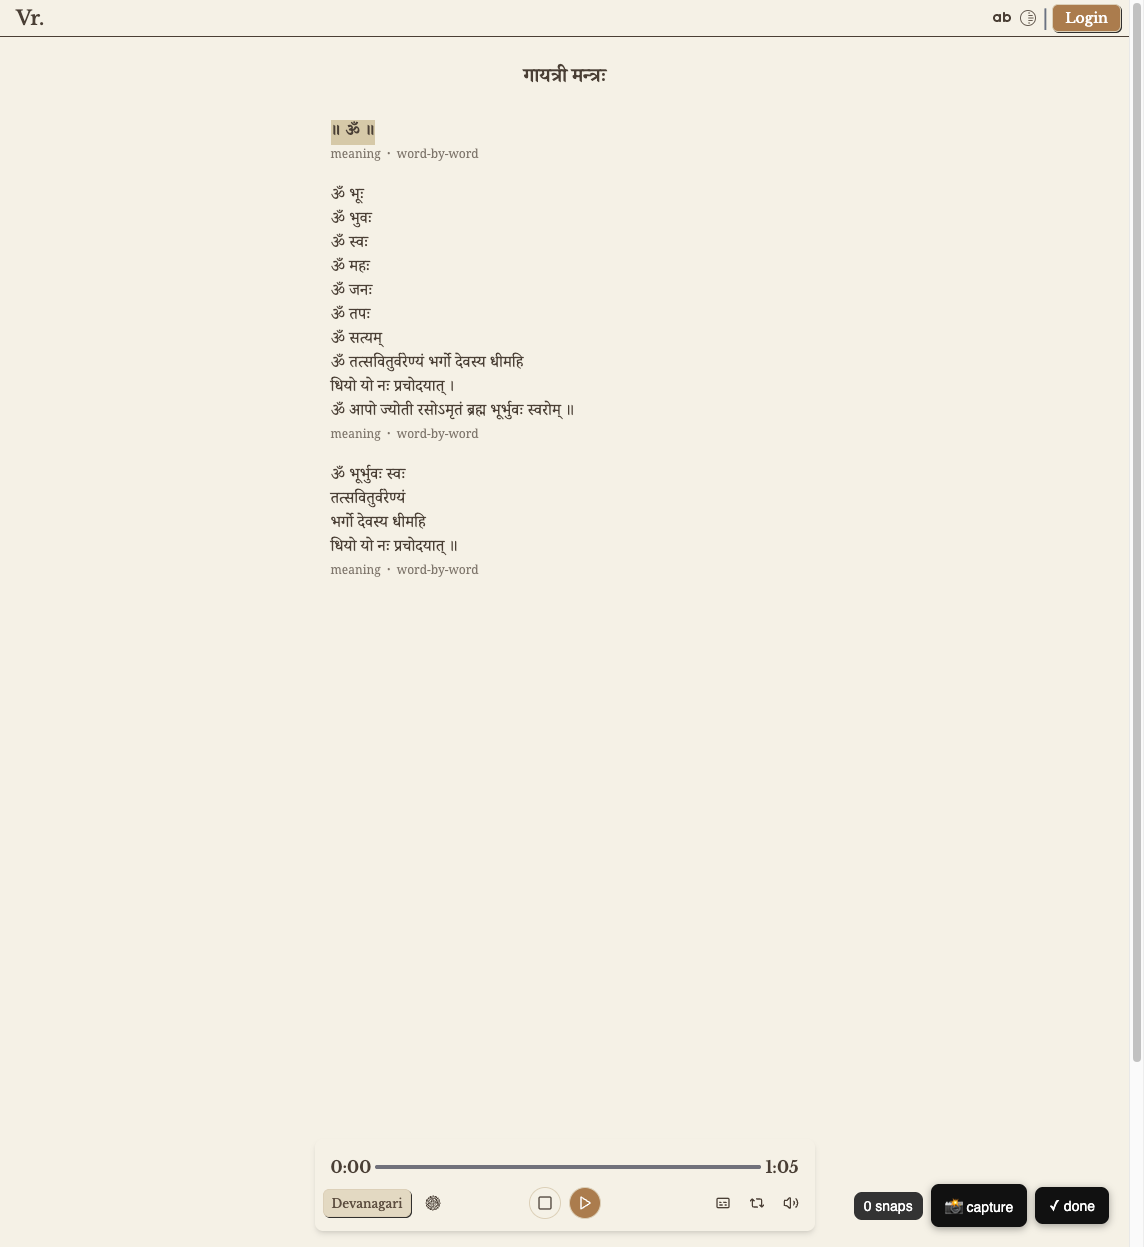

In [ ]:
#| eval: false
imgs = syncy(page.collect(count=1, tout=5, every_n=1))
if imgs: imgs[0].width, imgs[0].height = 200, 400
imgs[0]

In [ ]:
#| export
ANNOTATE_JS = r"""(function(){if(window.__axOn) return;
window.__axOn=true; window.__axN=0;const hov=document.createElement('div');hov.id='__axhov';
hov.style.cssText='position:fixed;pointer-events:none;z-index:999998;outline:2px solid #3b82f6;border-radius:2px;background:rgba(59,130,246,0.08);display:none;box-sizing:border-box;';
document.body.appendChild(hov);
window.__axBadge=function(n,role,sel){
  const el=document.querySelector('[data-axid="'+n+'"]');
  if(!el) return;
  el.style.outline='2px solid #2563eb';
  el.style.outlineOffset='1px';
  const b=document.createElement('div');
  b.className='__axbadge';
  const r=el.getBoundingClientRect();
  b.style.cssText='position:fixed;z-index:999999;pointer-events:none;'
    +'top:'+r.top+'px;right:'+(window.innerWidth-r.right)+'px;'
    +'background:rgba(30,64,175,.92);color:#fff;font:bold 11px/1.4 monospace;'
    +'padding:2px 6px;border-radius:0 2px 0 4px;white-space:nowrap;';
  b.textContent=n+' '+role+' · '+sel;
  document.body.appendChild(b);
  const c=document.getElementById('__axcount');
  if(c) c.textContent=n+' selected';
};
function getSel(el){
  if(el.id) return '#'+CSS.escape(el.id);
  if(el.dataset.testid) return '[data-testid="'+el.dataset.testid+'"]';
  let s=el.tagName.toLowerCase();
  const t=el.getAttribute('type');
  if(t) s+='[type="'+t+'"]';
  else if(el.className) s+='.'+el.className.trim().split(/\s+/)[0];
  return s;
}
document.addEventListener('mousemove',function(e){
  const el=document.elementFromPoint(e.clientX,e.clientY);
  if(!el||el.closest('#__axbar,#__axhov')){hov.style.display='none';return;}
  const r=el.getBoundingClientRect();
  Object.assign(hov.style,{display:'block',left:r.left+'px',top:r.top+'px',width:r.width+'px',height:r.height+'px'});
},true);
document.addEventListener('click',function(e){
  const el=document.elementFromPoint(e.clientX,e.clientY);
  if(!el||el.closest('#__axbar')) return;
  e.preventDefault(); e.stopPropagation();
  const n=++window.__axN;
  el.setAttribute('data-axid',n);
  window.__axsel(JSON.stringify({n:n,sel:getSel(el),x:e.clientX,y:e.clientY}));
},true);
})();"""

ANNOTATE_BAR_JS = '''(function(){
    if(document.getElementById('__axbar')) return;
    const bar=document.createElement('div');
    bar.id='__axbar';bar.style.cssText='position:fixed;bottom:16px;left:50%;transform:translateX(-50%);z-index:1000000;background:#1e40af;color:#fff;padding:8px 20px;border-radius:999px;font:bold 13px system-ui;box-shadow:0 4px 12px rgba(0,0,0,.3);display:flex;gap:12px;align-items:center;user-select:none;';
    bar.innerHTML='<span id="__axcount">0 selected</span><button style="background:#fff;color:#1e40af;border:none;padding:4px 14px;border-radius:999px;font:bold 12px system-ui;cursor:pointer;" onclick="window.__axsel(JSON.stringify({done:true}))">✓ Done</button>';
    document.body.appendChild(bar);})();'''

ANNOTATE_CLEANUP_JS = '''document.querySelectorAll('[data-axid]').forEach(e=>{e.removeAttribute('data-axid');
e.style.outline='';e.style.outlineOffset='';});document.querySelectorAll('[data-axb]').forEach(e=>e.remove());
document.querySelectorAll('.__axbadge').forEach(e=>e.remove());
['__axhov','__axbar'].forEach(id=>document.getElementById(id)?.remove());
['__axOn','__axN','__axBadge','__axsel'].forEach(k=>delete window[k]);'''
_AX_SKIP = {'none','generic','Section','InlineTextBox','StaticText',''}

In [ ]:
#| export
@patch
async def annotate(page:Page, save_dir=None, prefix=None, stop=None, tout=None):
	"Click elements interactively; returns (screenshot, [{n, role, name, selector}]) with badges baked in."
	stop, sid = stop or asyncio.Event(), page.sid
	prefix = prefix or await page.eval('document.title')
	save_dir = Path(save_dir) if save_dir else None
	if save_dir: save_dir.mkdir(parents=True, exist_ok=True)
	await page.runtime.enable()
	await page.accessibility.enable()
	await page.runtime.addBinding(name='__axsel')
	ident = await page.page.addScriptToEvaluateOnNewDocument(source=ANNOTATE_JS)
	await page.eval(ANNOTATE_JS)
	await page.eval(ANNOTATE_BAR_JS)
	loop = asyncio.get_event_loop()
	dl = loop.time() + tout if tout else None
	selected, img = [], None
	try:
		async with page.cdp.on('Runtime.bindingCalled') as q:
			print('Click elements to annotate, ✓ Done when ready.')
			while not stop.is_set():
				rem = (dl - loop.time()) if dl else None
				if rem is not None and rem <= 0: break
				get, halt = asyncio.ensure_future(q.get()), asyncio.ensure_future(stop.wait())
				fin, pend = await asyncio.wait({get, halt}, return_when=asyncio.FIRST_COMPLETED,timeout=rem)
				for p in pend: p.cancel()
				if get not in fin: break
				m = get.result()
				if m.get('sessionId') not in (None, sid) or m['params'].get('name') != '__axsel': continue
				data = json.loads(m['params'].get('payload') or '{}')
				if data.get('done'): break
				n, sel = data['n'], data['sel']
				loc = await page.DOM.getNodeForLocation(x=int(data['x']), y=int(data['y']),
					includeUserAgentShadowDOM=False)
				nodes = await page.accessibility.getAXNodeAndAncestors(backendNodeId=loc['backendNodeId'])
				role = next((nd['role']['value'] for nd in nodes
				             if nd.get('role',{}).get('value','') not in _AX_SKIP), 'element')
				name = next((nd['name']['value'] for nd in nodes
				             if nd.get('name',{}).get('value','')), '')
				await page.eval(f"window.__axBadge({json.dumps(n)},{json.dumps(role)},{json.dumps(sel)})")
				selected.append({'n': n, 'role': role, 'name': name, 'selector': sel})
		img = await page.screenshot()
	finally:
		try:
			await page.page.removeScriptToEvaluateOnNewDocument(identifier=ident)
			await page.runtime.removeBinding(name='__axsel')
			await page.eval(ANNOTATE_CLEANUP_JS)
		except Exception: pass
	if save_dir and img:
		f = save_dir / f'{prefix}.png'
		f.write_bytes(img.data)
		print('saved', f.name)
	return img, selected

Click elements to annotate, ✓ Done when ready.
saved Gayathri Dhyaanam.png


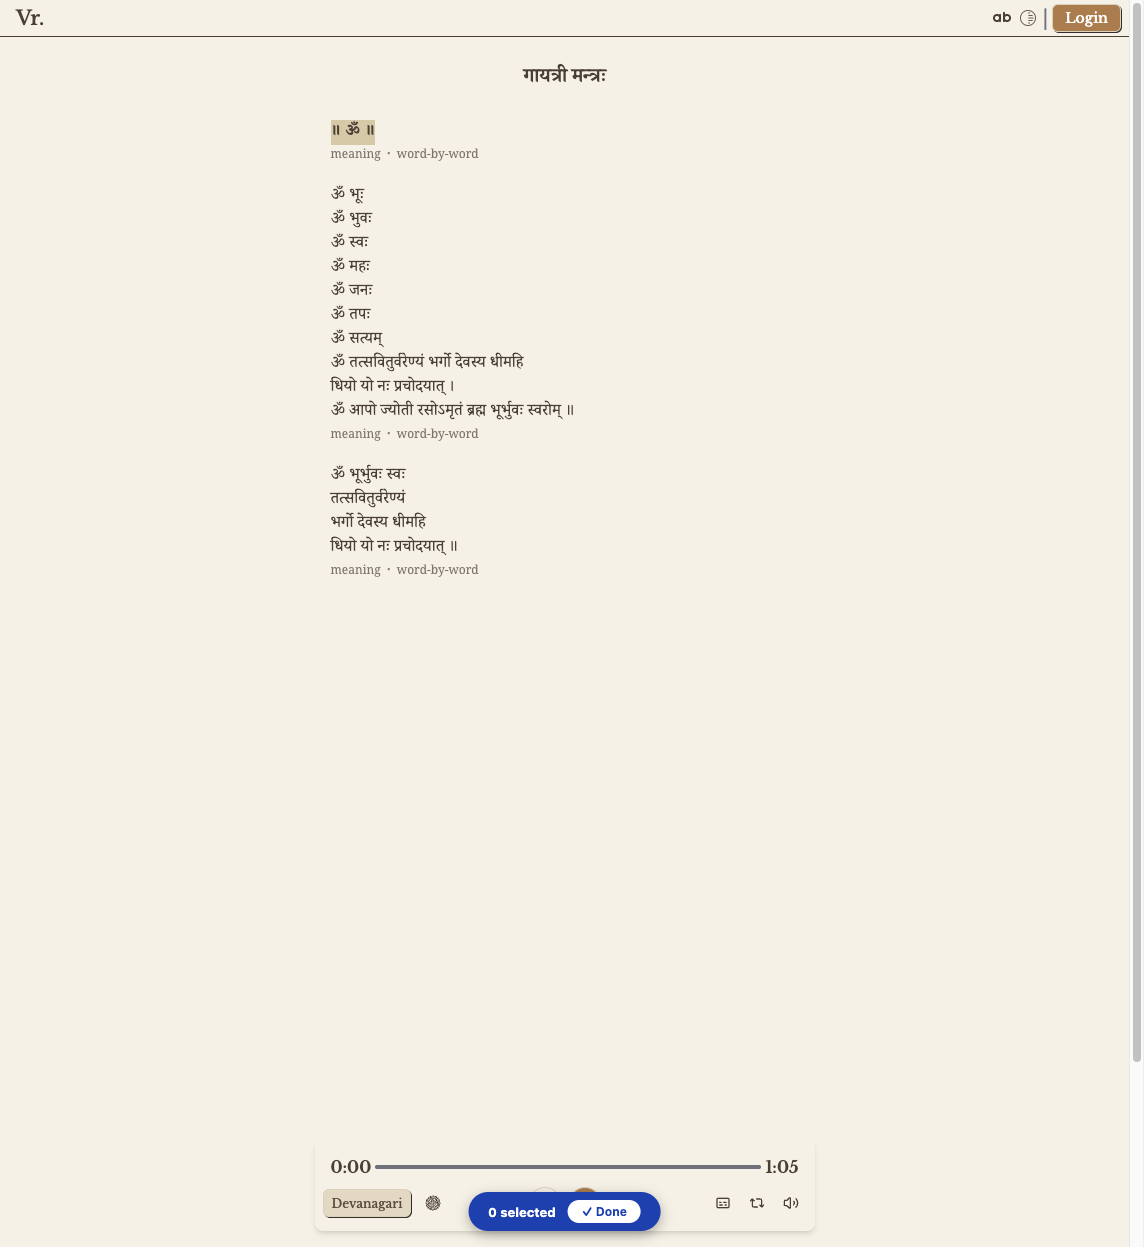

In [ ]:
#| eval: false
img, elements = syncy(page.annotate(save_dir='shots', tout=2))
img.height, img.width = 400, 200
img

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()